In [8]:
import glob
import re

import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math
from utils import Graph
from mpl_toolkits.mplot3d import Axes3D
import itertools

file_tree = {}
for i in range(0, 100):  
    for file in glob.glob(f'simulation-runs/500V_{i}.txt'):
        key = int(re.search(r'(\d+)', file).group(1))
        if key in file_tree:
            file_tree[key].append(file)
        else:
            file_tree[key] = [file]



## Recombination Classification

In [9]:
import glob
import re

avg_y = 0.0

# Distance in microns between each argon
r_k = 0.040   # µm

angle = 90  # degrees
rad   = np.deg2rad(angle)
cosA, sinA = np.cos(rad), np.sin(rad)

# Maximum distance in x-direction
r_max = 4

# Run range (inclusive)
run_start = 1
run_end = 100

def run_number(path):
    match = re.search(r'_(\d+)\.txt$', path)
    return int(match.group(1)) if match else -1

selected_files = []
for i in range(run_start, run_end + 1):
    matches = glob.glob(f'simulation-runs/500V_{i}.txt')
    if not matches:
        print(f'Warning: missing file for run {i}')
    selected_files.extend(matches)

selected_files = sorted(selected_files, key=run_number)
total_runs_loaded = len(selected_files)
print(f'Loaded {total_runs_loaded} files for runs {run_start}..{run_end}')

def extract_coordinates(file, electron_key):
    with open(file, 'r') as f:
        ke_column = []
        results   = []
        row_list  = []

        lines      = f.readlines()
        num_lines  = len(lines)

        for i in range(0, num_lines, 1):
            cols = list(map(float, filter(None, lines[i].strip().split(','))))
            x, y, z, ke = cols[1], cols[2], cols[3], cols[5]
            row_number  = i

            if not ke_column:
                ke_column.append(ke)

            # Projection of (x,z) onto the tilted ion line
            s_proj = x * cosA + z * sinA

            # Closest lattice site coordinate along the line
            s_near = round(s_proj / r_k) * r_k

            # Ion coordinates
            x_i = s_near * cosA
            z_i = s_near * sinA

            # Euclidean distance to that ion
            closest_distance = np.sqrt((x - x_i)**2 + y**2 + (z - z_i)**2)

            # Recombination or escape logic
            if x > r_max:
                results.append(1)
                row_list.append(row_number)
            elif closest_distance < 0.001229 and ke < 1.0:
                results.append(-1)
                row_list.append(row_number)
            else:
                results.append(0)

    return results, row_list

# Lists to store overall results
all_results = []
occurence_list = []
file_row_list = {}

for electron_index, file in enumerate(selected_files):
    electron_key = f'electron_{electron_index}'

    # UNPACK the two returns properly
    results_list, row_list = extract_coordinates(file, electron_key)

    # 'results_list' is the integer list [-1, 0, 1]
    all_results.append(results_list)

    # Save row_list if desired
    file_row_list[file] = row_list

    # Determine outcome
    if 1 in results_list:
        if -1 not in results_list:
            outcome = 'escapes'
            occurence_list.append(1)
        else:
            first_index_1 = results_list.index(1)
            first_index_minus_1 = results_list.index(-1)
            if first_index_1 < first_index_minus_1:
                outcome = 'escapes'
                occurence_list.append(1)
            else:
                outcome = 'recombines'
                occurence_list.append(-1)
    elif -1 in results_list:
        outcome = 'recombines'
        occurence_list.append(-1)
    else:
        outcome = 'undetermined'
        occurence_list.append(0)

    print(f'File: {file}')
    print(f'Outcome: {outcome}')

if total_runs_loaded == 0:
    raise ValueError('No simulation files were loaded for the selected run range.')

escape_count = occurence_list.count(1)
recomb_count = occurence_list.count(-1)
undetermined_count = occurence_list.count(0)

# Probability over loaded runs
prob_recomb = recomb_count / total_runs_loaded
prob_escape = escape_count / total_runs_loaded

print('Occurrence List:', occurence_list)
print(f'Counts -> escape: {escape_count}, recombination: {recomb_count}, undetermined: {undetermined_count}, total: {total_runs_loaded}')
print(f'Escape Probability: {prob_escape:.6f} Recombination Probability: {prob_recomb:.6f}')


Loaded 20 files for runs 1..100
File: simulation-runs/500V_1.txt
Outcome: escapes
File: simulation-runs/500V_2.txt
Outcome: recombines
File: simulation-runs/500V_3.txt
Outcome: recombines
File: simulation-runs/500V_4.txt
Outcome: escapes
File: simulation-runs/500V_5.txt
Outcome: recombines
File: simulation-runs/500V_6.txt
Outcome: recombines
File: simulation-runs/500V_7.txt
Outcome: escapes
File: simulation-runs/500V_8.txt
Outcome: escapes
File: simulation-runs/500V_9.txt
Outcome: escapes
File: simulation-runs/500V_10.txt
Outcome: recombines
File: simulation-runs/500V_11.txt
Outcome: escapes
File: simulation-runs/500V_12.txt
Outcome: escapes
File: simulation-runs/500V_13.txt
Outcome: undetermined
File: simulation-runs/500V_14.txt
Outcome: undetermined
File: simulation-runs/500V_15.txt
Outcome: recombines
File: simulation-runs/500V_16.txt
Outcome: recombines
File: simulation-runs/500V_17.txt
Outcome: recombines
File: simulation-runs/500V_18.txt
Outcome: escapes
File: simulation-runs/500

## Initial Coordinates of Electrons

In [10]:
# Initialize lists to store initial x, y, z coordinates
initial_x = []
initial_y = []
initial_z = []

# Function to extract initial coordinates from a file
def extract_initial_coordinates(file):
    with open(file, 'r') as f:
        # Assuming the first line contains the x, y, z coordinates in columns 2, 3, and 4
        line = f.readline().strip()
        # Split by comma and convert to float, filtering out any empty strings
        columns = list(map(float, filter(None, line.split(','))))
        x, y, z = columns[1], columns[2], columns[3]
        return x, y, z

# Process each group of files and extract initial coordinates
for key, value in sorted(file_tree.items()):
    print(key)
    group = Graph(value)
    
    # Extract initial coordinates from each file in the group
    for file in value:
        x, y, z = extract_initial_coordinates(file)
        initial_x.append(x)
        initial_y.append(y)
        initial_z.append(z)

# Convert lists to numpy arrays
initial_x = np.array(initial_x)
initial_y = np.array(initial_y)
initial_z = np.array(initial_z)

# Print or use the arrays as needed
print("Initial X coordinates:", initial_x)
print("Initial Y coordinates:", initial_y)
print("Initial Z coordinates:", initial_z)

500
Initial X coordinates: [ 1.07159e-04 -1.33741e-03 -6.40742e-04 -2.87165e-05 -3.62424e-04
 -5.57854e-04  1.37462e-03  1.05268e-03 -1.28540e-03 -7.87580e-04
  3.90829e-04  8.90007e-06  2.00802e-06  1.08856e-04 -1.77838e-04
 -1.70092e-03 -1.63855e-04  2.79263e-04 -2.21549e-03 -1.26127e-03]
Initial Y coordinates: [-1.68791e-03  2.56354e-04  2.41605e-05 -1.55995e-03  5.64269e-04
  1.05383e-04  3.39477e-05 -3.36361e-04  4.02171e-04  6.26658e-04
 -1.53549e-03 -1.11256e-04  1.29388e-03 -3.55851e-04 -7.64694e-04
 -3.22258e-04  6.03491e-04  4.24446e-04  1.86490e-03 -3.74018e-04]
Initial Z coordinates: [-1.03532e-03  1.74498e-03 -4.32579e-07  3.49765e-04  8.70197e-04
 -6.61380e-04  1.46894e-03  1.22006e-04  8.95283e-04  2.04953e-04
 -1.55948e-04 -6.99587e-05 -6.71831e-04 -4.09348e-04 -1.34285e-04
  1.65090e-03 -7.83816e-04 -9.99716e-04  2.15275e-04 -1.26971e-03]


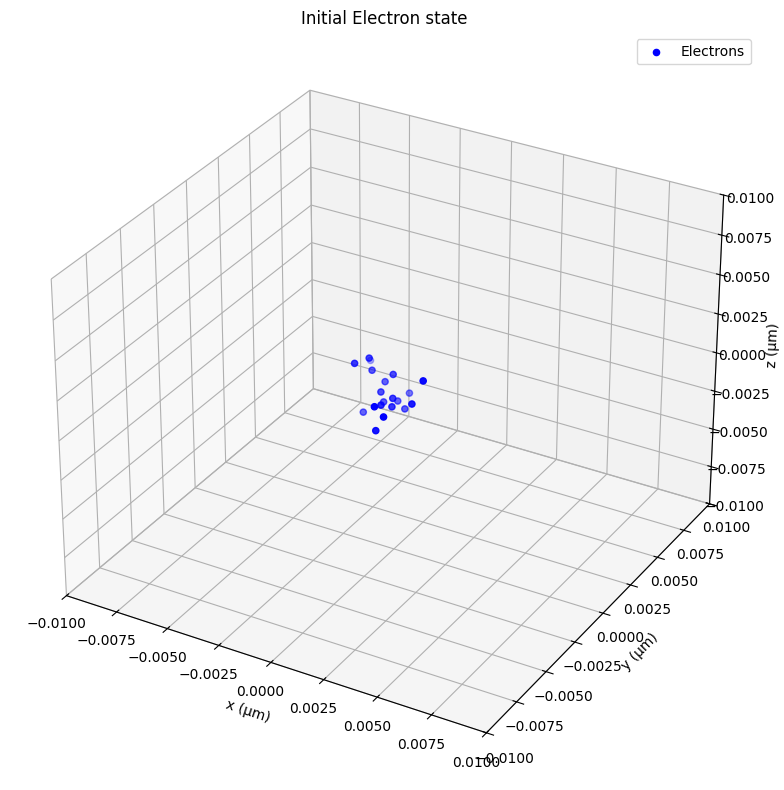

In [15]:
# ---------- user knobs ----------------------------------------------------
r_k_nm      = 100      # lattice spacing, nm
angle_deg   = 90    # tilt angle: 0° = +x axis, 90° = +z axis
# -------------------------------------------------------------------------

spacing_um  = r_k_nm / 1000.0                # nm → µm
rad         = np.deg2rad(angle_deg)          # degrees → radians
cosA, sinA  = np.cos(rad), np.sin(rad)

indices     = np.arange(-10, 10)             # 21 ions (−10 … +10)

# ion coordinates
lattice_x   = indices * spacing_um * cosA
lattice_y   = np.zeros_like(lattice_x)
lattice_z   = indices * spacing_um * sinA



fig = plt.figure(figsize=(8, 8))
ax  = fig.add_subplot(111, projection='3d')

ax.scatter(initial_x, initial_y, initial_z,
           s=20, c='blue',  depthshade=True,  label='Electrons')

ax.set_title('Initial Electron state')
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_zlabel('z (µm)')

ax.set_xlim(-0.01, 0.01)
ax.set_ylim(-0.01, 0.01)
ax.set_zlim(-0.01, 0.01)
ax.legend()
plt.tight_layout()
plt.show()



IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

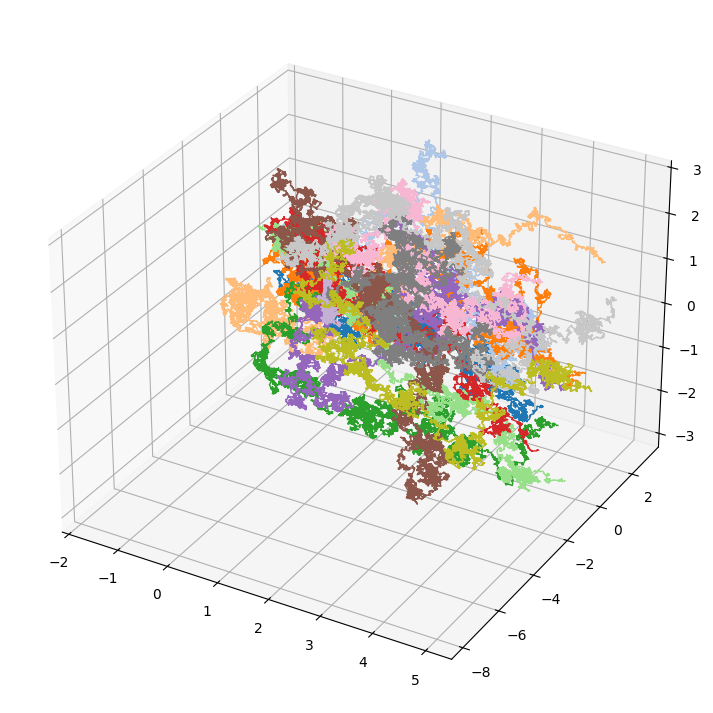

In [ ]:
fig = plt.figure(figsize=(11, 9))
ax  = fig.add_subplot(111, projection="3d")

color_cycle = itertools.cycle(plt.cm.tab20.colors)

for key, files in sorted(file_tree.items()):
    for file in files:
        data = np.loadtxt(file, delimiter=",")[::5]          # every 5 th row
        x, y, z = data[:, 1], data[:, 2], data[:, 3]
        col = next(color_cycle)

        ax.plot(x, y, z, lw=1, color=col)

        if len(x) > 1:                                       # arrow at the end
            dx, dy, dz = x[-1] - x[-2], y[-1] - y[-2], z[-1] - z[-2]
            ax.quiver(
                x[-2], y[-2], z[-2],
                dx,    dy,    dz,
                color=col,
                arrow_length_ratio=0.2,
                linewidth=1
            )

ax.set_title("Electron Trajectories")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_zlabel("z (nm)")

plt.tight_layout()
plt.show()
